<a href="https://colab.research.google.com/github/ODUNAYOMIDE-YAKUBU/sentiment_chatbot/blob/main/phase3_bert_lstm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformers torch scikit-learn pandas numpy -q

In [ ]:
from google.colab import files
uploaded = files.upload()  # upload data_train.csv, data_val.csv, data_test.csv

Saving data_full.csv to data_full.csv
Saving data_test.csv to data_test.csv
Saving data_train.csv to data_train.csv
Saving data_val.csv to data_val.csv


In [ ]:
import pandas as pd

train = pd.read_csv("data_train.csv")
val   = pd.read_csv("data_val.csv")
test  = pd.read_csv("data_test.csv")

print(f"Train: {len(train)} | Val: {len(val)} | Test: {len(test)}")
print(train['sentiment'].value_counts())
print(train.head())

Train: 4475 | Val: 959 | Test: 960
sentiment
negative    2051
positive    2042
neutral      382
Name: count, dtype: int64
                                                text  label sentiment
0  ahh im gonna go to bed and sleep wats left of ...      0  negative
1                        nthn muchmad this damn rain      0  negative
2  what me im kuku waiting for is the long list o...      2  positive
3                        london dev meet awesomeness      2  positive
4  if you just do like jew nah wahala oh my eyes ...      0  negative


In [ ]:
import torch
print("GPU available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

GPU available: True
Device: Tesla T4


In [ ]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Test it works
sample = "I am so happy today abeg"
tokens = tokenizer(sample, return_tensors="pt")
print("Tokenizer working!")
print(tokens)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizer working!
{'input_ids': tensor([[  101,  1045,  2572,  2061,  3407,  2651, 14863,  2290,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1]])}


In [ ]:
# Build PyTorch Dataset class
from torch.utils.data import Dataset

class SentimentDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.texts  = df['text'].tolist()
        self.labels = df['label'].tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = SentimentDataset(train, tokenizer)
val_dataset   = SentimentDataset(val,   tokenizer)
test_dataset  = SentimentDataset(test,  tokenizer)

print(f"Train batches: {len(train_dataset)}")
print(f"Val batches:   {len(val_dataset)}")
print("Dataset class ready!")

Train batches: 4475
Val batches:   959
Dataset class ready!


In [ ]:
#  Create Dataloader

from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False)

print("DataLoaders ready!")

DataLoaders ready!


In [ ]:
import torch.nn as nn
from transformers import BertModel

class BertLSTMClassifier(nn.Module):
    def __init__(self, bert_model_name="bert-base-uncased",
                 hidden_dim=256, num_layers=2,
                 num_classes=3, dropout=0.3):
        super(BertLSTMClassifier, self).__init__()

        # BERT encoder
        self.bert = BertModel.from_pretrained(bert_model_name)

        # LSTM on top of BERT output
        self.lstm = nn.LSTM(
            input_size=768,       # BERT hidden size
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True    # reads text forwards AND backwards
        )

        # Classification head
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, num_classes)  # *2 for bidirectional

    def forward(self, input_ids, attention_mask):
        # Get BERT contextual embeddings
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = bert_out.last_hidden_state  # (batch, seq_len, 768)

        # Pass through LSTM
        lstm_out, _ = self.lstm(sequence_output)      # (batch, seq_len, 512)

        # Take the last timestep output
        lstm_final = lstm_out[:, -1, :]               # (batch, 512)

        # Dropout + classify
        out = self.dropout(lstm_final)
        logits = self.classifier(out)                 # (batch, 3)
        return logits

model = BertLSTMClassifier().to(device)
print("BERT-LSTM model built successfully!")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT-LSTM model built successfully!
Total parameters: 113,161,987


In [ ]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights to handle neutral class imbalance
classes = np.array([0, 1, 2])
weights = compute_class_weight('balanced',classes=classes, y=train['label'].values)
class_weights = torch.tensor(weights, dtype=torch.float).to(device)

print("Class weights:", class_weights)

# Loss with class weighting — penalizes neutral misclassification more
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer — lower LR for BERT to avoid catastrophic forgetting
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

# Learning rate scheduler
from transformers import get_linear_schedule_with_warmup
total_steps = len(train_loader) * 5  # 5 epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)
print("Optimizer and scheduler ready!")

Class weights: tensor([0.7273, 3.9049, 0.7305], device='cuda:0')
Optimizer and scheduler ready!


In [ ]:
from sklearn.metrics import accuracy_score, f1_score

def train_epoch(model, loader, optimizer, criterion, scheduler, device):
    model.train()
    total_loss, all_preds, all_labels = 0, [], []
    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)
        loss   = criterion(logits, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc      = accuracy_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds, average='weighted')
    return avg_loss, acc, f1

def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            logits = model(input_ids, attention_mask)
            loss   = criterion(logits, labels)

            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc      = accuracy_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds, average='weighted')
    return avg_loss, acc, f1

print("Training functions ready!")

Training functions ready!


In [ ]:
EPOCHS = 5
best_val_f1 = 0
history = []

print("Starting training...\n")
for epoch in range(EPOCHS):
    train_loss, train_acc, train_f1 = train_epoch(
        model, train_loader, optimizer, criterion, scheduler, device)
    val_loss, val_acc, val_f1 = eval_epoch(
        model, val_loader, criterion, device)

    history.append({
        'epoch': epoch+1,
        'train_loss': train_loss, 'train_acc': train_acc, 'train_f1': train_f1,
        'val_loss': val_loss,     'val_acc': val_acc,     'val_f1': val_f1
    })

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"  Train → Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | F1: {train_f1:.4f}")
    print(f"  Val   → Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f}")

    # Save best model
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), "bert_lstm_best.pt")
        print(f"  ✓ Best model saved (Val F1: {best_val_f1:.4f})")
    print()

print(f"Training complete! Best Val F1: {best_val_f1:.4f}")

Starting training...

Epoch 1/5
  Train → Loss: 0.9661 | Acc: 0.5068 | F1: 0.5121
  Val   → Loss: 0.8813 | Acc: 0.6486 | F1: 0.6467
  ✓ Best model saved (Val F1: 0.6467)

Epoch 2/5
  Train → Loss: 0.7355 | Acc: 0.6845 | F1: 0.6846
  Val   → Loss: 0.7441 | Acc: 0.6851 | F1: 0.6822
  ✓ Best model saved (Val F1: 0.6822)

Epoch 3/5
  Train → Loss: 0.5730 | Acc: 0.7620 | F1: 0.7611
  Val   → Loss: 0.9582 | Acc: 0.6809 | F1: 0.6758

Epoch 4/5
  Train → Loss: 0.4494 | Acc: 0.8118 | F1: 0.8105
  Val   → Loss: 0.9766 | Acc: 0.7018 | F1: 0.7018
  ✓ Best model saved (Val F1: 0.7018)

Epoch 5/5
  Train → Loss: 0.3587 | Acc: 0.8474 | F1: 0.8471
  Val   → Loss: 1.0599 | Acc: 0.7070 | F1: 0.7061
  ✓ Best model saved (Val F1: 0.7061)

Training complete! Best Val F1: 0.7061


Test Accuracy: 0.6969
Test F1 Score: 0.6955

Classification Report:
              precision    recall  f1-score   support

    negative       0.74      0.70      0.72       440
     neutral       0.51      0.44      0.47        82
    positive       0.68      0.74      0.71       438

    accuracy                           0.70       960
   macro avg       0.65      0.63      0.64       960
weighted avg       0.70      0.70      0.70       960



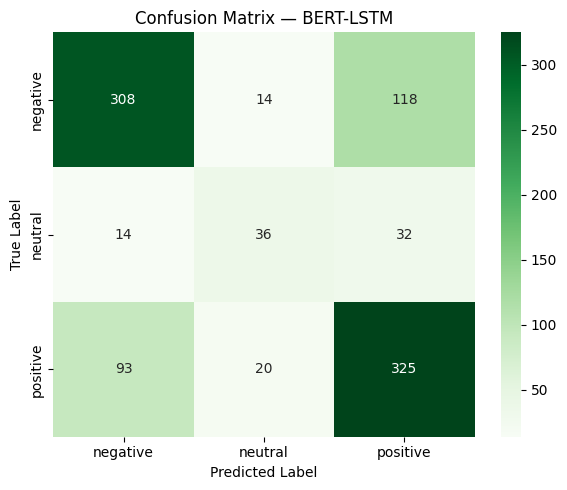

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load best model
model.load_state_dict(torch.load("bert_lstm_best.pt"))
test_loss, test_acc, test_f1 = eval_epoch(model, test_loader, criterion, device)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")

# Detailed classification report
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)
        logits         = model(input_ids, attention_mask)
        preds          = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

label_names = ['negative', 'neutral', 'positive']
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=label_names))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
    xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix — BERT-LSTM')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

In [ ]:
from google.colab import files
files.download("bert_lstm_best.pt")
files.download("confusion_matrix.png")

In [ ]:
# Retrain with improvements (longer training + unfreezing BERT layers)
# Unfreeze last 4 BERT layers for better fine-tuning
for name, param in model.bert.named_parameters():
    if any(f"encoder.layer.{i}" in name for i in [8, 9, 10, 11]):
        param.requires_grad = True
    else:
        param.requires_grad = False  # freeze early layers

# New optimizer with layer-wise learning rates
optimizer2 = torch.optim.AdamW([
    {'params': model.bert.parameters(),       'lr': 1e-5},  # slower for BERT
    {'params': model.lstm.parameters(),       'lr': 3e-4},  # faster for LSTM
    {'params': model.classifier.parameters(), 'lr': 3e-4}   # faster for head
], weight_decay=0.01)

EPOCHS2 = 4
total_steps2 = len(train_loader) * EPOCHS2
scheduler2 = get_linear_schedule_with_warmup(
    optimizer2,
    num_warmup_steps=total_steps2 // 10,
    num_training_steps=total_steps2
)

# Stronger class weights for neutral
class_weights2 = torch.tensor([1.0, 4.0, 1.0], dtype=torch.float).to(device)
criterion2 = nn.CrossEntropyLoss(weight=class_weights2)

print("Fine-tuning setup ready!")

Fine-tuning setup ready!


In [ ]:
best_val_f1_v2 = 0

print("Fine-tuning started...\n")
for epoch in range(EPOCHS2):
    train_loss, train_acc, train_f1 = train_epoch(
        model, train_loader, optimizer2, criterion2, scheduler2, device)
    val_loss, val_acc, val_f1 = eval_epoch(
        model, val_loader, criterion2, device)

    print(f"Epoch {epoch+1}/{EPOCHS2}")
    print(f"  Train → Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | F1: {train_f1:.4f}")
    print(f"  Val   → Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f}")

    if val_f1 > best_val_f1_v2:
        best_val_f1_v2 = val_f1
        torch.save(model.state_dict(), "bert_lstm_best_v2.pt")
        print(f"  ✓ Best model saved (Val F1: {best_val_f1_v2:.4f})")
    print()

print(f"Fine-tuning complete! Best Val F1: {best_val_f1_v2:.4f}")

Fine-tuning started...

Epoch 1/4
  Train → Loss: 0.3434 | Acc: 0.8570 | F1: 0.8569
  Val   → Loss: 1.3500 | Acc: 0.7007 | F1: 0.6973
  ✓ Best model saved (Val F1: 0.6973)

Epoch 2/4
  Train → Loss: 0.3243 | Acc: 0.8764 | F1: 0.8764
  Val   → Loss: 1.2828 | Acc: 0.6820 | F1: 0.6820

Epoch 3/4
  Train → Loss: 0.2955 | Acc: 0.8829 | F1: 0.8828
  Val   → Loss: 1.3852 | Acc: 0.6966 | F1: 0.6934

Epoch 4/4
  Train → Loss: 0.2719 | Acc: 0.8956 | F1: 0.8956
  Val   → Loss: 1.3669 | Acc: 0.7122 | F1: 0.7101
  ✓ Best model saved (Val F1: 0.7101)

Fine-tuning complete! Best Val F1: 0.7101


Test Accuracy: 0.6990
Test F1 Score: 0.6974

Classification Report:
              precision    recall  f1-score   support

    negative       0.72      0.75      0.73       440
     neutral       0.49      0.43      0.45        82
    positive       0.71      0.70      0.71       438

    accuracy                           0.70       960
   macro avg       0.64      0.63      0.63       960
weighted avg       0.70      0.70      0.70       960



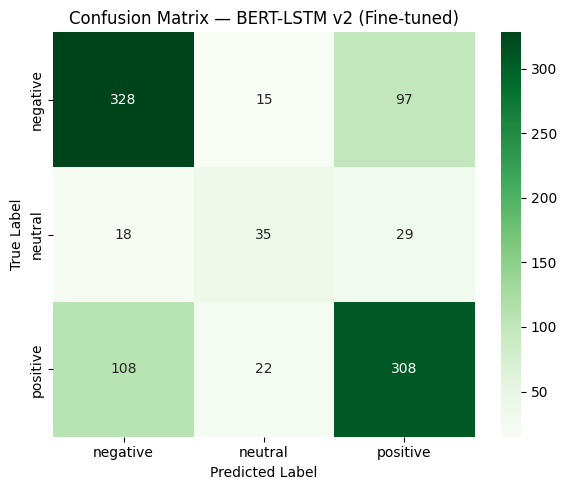

In [ ]:
model.load_state_dict(torch.load("bert_lstm_best_v2.pt"))
test_loss, test_acc, test_f1 = eval_epoch(model, test_loader, criterion2, device)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)
        logits         = model(input_ids, attention_mask)
        preds          = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

label_names = ['negative', 'neutral', 'positive']
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=label_names))

# Updated confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
    xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix — BERT-LSTM v2 (Fine-tuned)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig("confusion_matrix_v2.png", dpi=150)
plt.show()

In [ ]:
from google.colab import files
files.download("bert_lstm_best_v2.pt")
# files.download("confusion_matrix_v2.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>